# Валидация датафрейма с описаниями мясных изделий

1. Изучить датасет
2. Произвести валидацию соответствия product и файлов с разрубами
3. Разработать и реализовать метод валидации description и product_type **(целевая)**
4. По возможности исправить невалидные классы

# Импорт

## Загрузка библиотек

In [1]:
import os
import re
import json
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from matplotlib import colors
from pandarallel import pandarallel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from pymystem3 import Mystem
from sentence_transformers import SentenceTransformer
import torch

from joblib import Parallel, delayed
from multiprocessing import cpu_count

pd.set_option("display.max_colwidth", 200)
pandarallel.initialize(progress_bar=True)

tqdm.pandas()

if torch.cuda.is_available():
    print("GPU доступно!")
    print(f"Текущий GPU: {torch.cuda.current_device()}")
    print(f"Имя GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU не доступно, используется CPU.")

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/
GPU не доступно, используется CPU.


## Пути к данным

In [2]:
datapath = "../../monitorings/meat/predictor/data"
dataset_v2_datapath = os.path.join(datapath, "meat_dataset_v2.csv")
mutton_datapath = os.path.join(datapath, "categories", "Баранина_разрубы.csv")
bird_datapath = os.path.join(datapath, "categories", "Птица_разрубы.csv")
pork_datapath = os.path.join(datapath, "categories", "Свинина_разрубы.csv")
beef_datapath = os.path.join(datapath, "categories", "Говядина_разрубы.csv")

# Загрузка и предобработка

- [x] Поиск и удаление дубликатов и пропусков
- [x] Маппинг утверждённых классов мяса **(папка categories)**
- [X] Просмотр классов размеченных и неразмеченных классов 
- [x] Выявление невалидных классов
- [x] Чиста текста от лишних символов и лемматизация
- [x] Коррекция названий классов

## Знакомство с данными

Классификация построена на описаниях продуктов, поэтому произведём проверку на наличие дубликатов и пропусков в **description**. Также загружаем датасеты с утверждёнными классами.

In [3]:
# основной датасет
df = pd.read_csv(dataset_v2_datapath, sep=";", index_col=0)

# датасеты с категориями
mutton = pd.read_csv(mutton_datapath, sep=";")
bird = pd.read_csv(bird_datapath, sep=";")
pork = pd.read_csv(pork_datapath, sep=";")
beef = pd.read_csv(beef_datapath, sep=";")

df_init_shape = df.shape

In [4]:
df = pd.read_csv(
    os.path.join(datapath, "meat_dataset_v2.csv"), delimiter=";", index_col=0
)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76403 entries, 0 to 76402
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product       76403 non-null  object
 1   description   76403 non-null  object
 2   product_type  76403 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB


In [6]:
# наличие дубликатов и пропусков
dubs = df.duplicated(subset=["description"]).sum()
nulls = df["description"].isna().sum()
print(f"Явных дубликатов в датафрейме (description): {dubs}")
print(f"Пропусков в датафрейме: {nulls}")

Явных дубликатов в датафрейме (description): 9360
Пропусков в датафрейме: 0


In [7]:
df[df['description'].str.contains('каре')]['product'].value_counts()

product
баранина    50
ягнятина    39
кура        38
цыпленок    21
телятина     2
Name: count, dtype: int64

In [8]:
meat_mapping = {
    # Говядина
    "говядина": "говядина",
    "телятина": "говядина",
    
    # Свинина
    "свинина": "свинина",
    "свиньи": "свинина",
    
    # Баранина
    "баранина": "баранина",
    "ягнятина": "баранина",
    
    # Птица
    "кура": "птица",
    "перепел": "птица",
    "утка": "птица",
    "цыпленок": "птица",
    "цесарка": "птица",
    "индейка": "птица",
    "гусь": "птица",
    "страус": "птица",
    "фазан": "птица",
    
    # Крольчатина
    "кролик": "крольчатина",
    
    # Буйволятина
    "буйволятина": "буйволятина",
    
    # Конина
    "конина": "конина",
}

In [9]:
# Применение маппинга
df["meat_type"] = df["product"].map(meat_mapping)

## Валидация классов в соответствии с categories

In [10]:
# обнаружены пропуски в value, удаляем
mutton = mutton.dropna(subset=["value"])

In [11]:
# приводим к нижнему регистру категории валидных продуктов
mutton.loc[:, "value"] = mutton.loc[:, "value"].apply(lambda string: string.lower())
bird.loc[:, "value"] = bird.loc[:, "value"].apply(lambda string: string.lower())
pork.loc[:, "value"] = pork.loc[:, "value"].apply(lambda string: string.lower())
beef.loc[:, "value"] = beef.loc[:, "value"].apply(lambda string: string.lower())

### Классы из разрубов

In [12]:
# функция для поиска невалидных категорий в основном датафрейме
def check_invalid_types(main_df: pd.DataFrame, validated_df: pd.DataFrame, meat_type: str):
    result = [
        cat for cat in main_df[main_df["meat_type"] == meat_type]["product_type"].unique()
        if cat not in validated_df.value.unique()
    ]
    print(f"Невалидные классы '{meat_type}':", result)

#### Птица

In [13]:
check_invalid_types(df, bird, 'птица')

Невалидные классы 'птица': ['филе', 'ноги', 'грудинка', 'шпик', 'голова', 'желудок', 'гузка', 'филе грубки', 'лопатка']


- [x] **Грудинка** удалить
- [x] **Лопатка** - удалить
- [x] **Филе** заменить на **филе грудки** | (**филе грубки** - опечатка)
- [x] **Голова** заменить на **головы**
- [x] **Ноги** и **лапы** - одно и то же
- [x] **Желудок** объединить с **желудки**
- [x] **Жир** = шпик

In [14]:
# правка классов для птицы на основе указаний аналитиков
df.loc[(df['meat_type'] == 'птица') & (df['product_type'] == 'филе'), 'product_type'] = 'филе грудки' # сделать замену в базе данных
df.loc[(df['meat_type'] == 'птица') & (df['product_type'] == 'филе грубки'), 'product_type'] = 'филе грудки'
df.loc[(df['meat_type'] == 'птица') & (df['product_type'] == 'голова'), 'product_type']  = 'головы'
df.loc[(df['meat_type'] == 'птица') & (df['product_type'] == 'желудок'), 'product_type'] = 'желудки'
df.loc[(df['meat_type'] == 'птица') & (df['product_type'] == 'ноги'), 'product_type']    = 'лапы'
df.loc[(df['meat_type'] == 'птица') & (df['product_type'] == 'гузка'), 'product_type']   = 'гузки'
df.loc[(df['meat_type'] == 'птица') & (df['product_type'] == 'шпик'), 'product_type']    = 'жир'

# удаление ненужных категорий
df = df[~((df['meat_type'] == 'птица') & (df['product_type'] == 'грудинка'))]
df = df[~((df['meat_type'] == 'птица') & (df['product_type'] == 'лопатка'))]

In [15]:
# проверка
check_invalid_types(df, bird, 'птица')

Невалидные классы 'птица': []


#### Свинина

In [16]:
check_invalid_types(df, pork, 'свинина')

Невалидные классы 'свинина': ['задние части', 'шкура', 'передние части', 'спинно-поясничный отруб ', 'набор для чахохбили', 'полутиши', 'губы', 'четвертины']


- [x] **Полутиши** = полутуши (опечатка)
- [x] **Кожа** = шкура
- [x] **Набор для чахохбили** - удалить
- [x] **Губы** - удалить
- [x] **Передняя и задняя части** - изменить 
      
Спинно-поясничный отруб, утранена ошибка с пробелом

In [17]:
# правка классов для птицы на основе указаний аналитиков
df.loc[(df['meat_type'] == 'свинина') & (df['product_type'] == 'полутиши'), 'product_type'] = 'полутуши'
df.loc[(df['meat_type'] == 'свинина') & (df['product_type'] == 'спинно-поясничный отруб '), 'product_type'] = 'спинно-поясничный отруб'
df.loc[(df['meat_type'] == 'свинина') & (df['product_type'] == 'шкура'), 'product_type'] = 'кожа' 
df.loc[(df['meat_type'] == 'свинина') & (df['product_type'] == 'задние части'), 'product_type'] = 'задняя четвертина' #
df.loc[(df['meat_type'] == 'свинина') & (df['product_type'] == 'передние части'), 'product_type'] = 'передняя четвертина' #

# удаление ненужных категорий
df = df[~((df['meat_type'] == 'свинина') & (df['product_type'] == 'набор для чахохбили'))] # 1 экземпляр
df = df[~((df['meat_type'] == 'свинина') & (df['product_type'] == 'губы'))] # 1 экземпляр
df = df[~((df['meat_type'] == 'свинина') & (df['product_type'] == 'четвертины'))] # 1 экземпляр

In [18]:
# проверка
check_invalid_types(df, pork, 'свинина')

Невалидные классы 'свинина': []


#### Говядина

In [19]:
check_invalid_types(df, beef, 'говядина')

Невалидные классы 'говядина': ['набор для бульона', 'односортная', 'котлетные части (котлета)', 'крыло', 'поясничная часть', 'спиной отруб']


- [x] **Набор для бульона** = набор для супа
- [x] **Котлетные части (котлета)** - убрать
- [x] **Крыло** - убрать
- [x] **Поясничная часть** - спинно-поясничный отруб
- [x] **Спиной отруб** = спинно-поясничный отруб(опечатка)

In [20]:
# правка классов для птицы на основе указаний аналитиков
df.loc[(df['meat_type'] == 'говядина') & (df['product_type'] == 'набор для бульона'), 'product_type'] = 'набор для супа'
df.loc[(df['meat_type'] == 'говядина') & (df['product_type'] == 'поясничная часть'), 'product_type'] = 'спинно-поясничный отруб'
df.loc[(df['meat_type'] == 'говядина') & (df['product_type'] == 'спиной отруб'), 'product_type'] = 'спинно-поясничный отруб' 

# удаление ненужных категорий
df = df[~((df['meat_type'] == 'говядина') & (df['product_type'] == 'котлетные части (котлета)'))] # 11 экземпляров
df = df[~((df['meat_type'] == 'говядина') & (df['product_type'] == 'крыло'))] # 1 экземпляр

In [21]:
# проверка
check_invalid_types(df, beef, 'говядина')

Невалидные классы 'говядина': ['односортная']


#### Баранина

In [22]:
check_invalid_types(df, mutton, 'баранина')

Невалидные классы 'баранина': ['котлетные части (котлета)', 'лопаточно-шейный отруб', 'голень', 'нос', 'набор для холодца']


- [x] **Котлетные части (котлета)** - ребро
- [x] **Лопаточно-шейный отруб** - лопаточно-шейная часть
- [x] **Гоялшка** - голень
- [x] **Нос** - убрать
- [x] **Набор для холдца** - убрать

In [23]:
# правка классов для птицы на основе указаний аналитиков
df.loc[(df['meat_type'] == 'баранина') & (df['product_type'] == 'котлетные части (котлета)'), 'product_type'] = 'ребро'
df.loc[(df['meat_type'] == 'баранина') & (df['product_type'] == 'лопаточно-шейный отруб'), 'product_type'] = 'лопаточно-шейная часть'
df.loc[(df['meat_type'] == 'баранина') & (df['product_type'] == 'голень'), 'product_type'] = 'голяшка'

# удаление ненужных категорий
df = df[~((df['meat_type'] == 'баранина') & (df['product_type'] == 'нос'))] # 1 экземпляр
df = df[~((df['meat_type'] == 'баранина') & (df['product_type'] == 'набор для холодца'))] # 1 экземпляр

In [24]:
# проверка
check_invalid_types(df, mutton, 'баранина')

Невалидные классы 'баранина': []


### Классы не входящие в разрубы

Крольчатина, буйволятина и конина не имеют специально размеченных таблиц.

In [25]:
def plot_classes_count(
    countings, 
    num_to_plot=None, 
    draw_percent_threshold=5, 
    title="Default_title", 
    figsize=(12, 7),
    vertical=False
):
    # pd.Series в pd.Datafraame
    countings = countings.sort_values(ascending=False).reset_index()
    countings.columns = ["cat", "value"]
    
    # если num_to_plot=None, то отрисовываем все значения
    if num_to_plot is None:
        plot_data = countings
        num_to_plot = len(countings)
    else:
        plot_data = countings.head(num_to_plot)
    
    # Создаем равномерно насыщенную палитру
    def vibrant_palette(n):
        # Красный (H=0), Зелёный (H=120) в HSV пространстве
        hues = np.linspace(0, 120, n)
        # Фиксированная высокая насыщенность (S=90%) и светлота (V=90%)
        return [colors.hsv_to_rgb([h/360, 0.9, 0.9]) for h in hues]  # Используем mcolors
    
    palette_colors = vibrant_palette(num_to_plot)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    if vertical:
        sns.barplot(
            x='cat', 
            y='value', 
            data=plot_data, 
            orient="v", 
            palette=palette_colors,
            ax=ax,
            saturation=1.0,
            hue='cat',       
            legend=False     
        )
        
        # поворот лейблов на 45 градусов
        plt.xticks(rotation=45, ha='right')
        
        # сумма объектов
        total = countings['value'].sum()
        
        # доли объектов класса
        for i, (cat, value) in enumerate(zip(plot_data['cat'], plot_data['value'])):
            percent = (value / total) * 100 
            percent_text = f"{percent:.1f}%" if percent >= 1 else f"{percent:.2f}%"
            
            ax.text(
                x=i,
                y=value + (countings.iloc[0].value * 0.005),  # немного выше колонки
                s=percent_text,
                ha="center",
                va="bottom",
                color="black",
                fontsize=12,
                fontweight='bold'
            )
    else:
        sns.barplot(
            x='value', 
            y='cat', 
            data=plot_data, 
            orient="h", 
            palette=palette_colors,
            ax=ax,
            saturation=1.0,
            hue='cat',       
            legend=False     
        )
        
        # сумма объектов
        total = countings['value'].sum()
        
        # доли объектов класса
        for i, (cat, value) in enumerate(zip(plot_data['cat'], plot_data['value'])):
            percent = (value / total) * 100 
            max_value = countings.iloc[0].value
            
            x_pos = max_value / 2
            text_color = "white" if percent >= (max_value / total) * 50 else "black"
            percent_text = f"{percent:.1f}%" if percent >= 1 else f"{percent:.2f}%"
            
            ax.text(
                x=x_pos,
                y=i,
                s=percent_text,
                ha="center",
                va="center",
                color=text_color,
                fontsize=12,
                fontweight='bold'
            )
    
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [26]:
# MEAT
meat_types = df["meat_type"].value_counts()

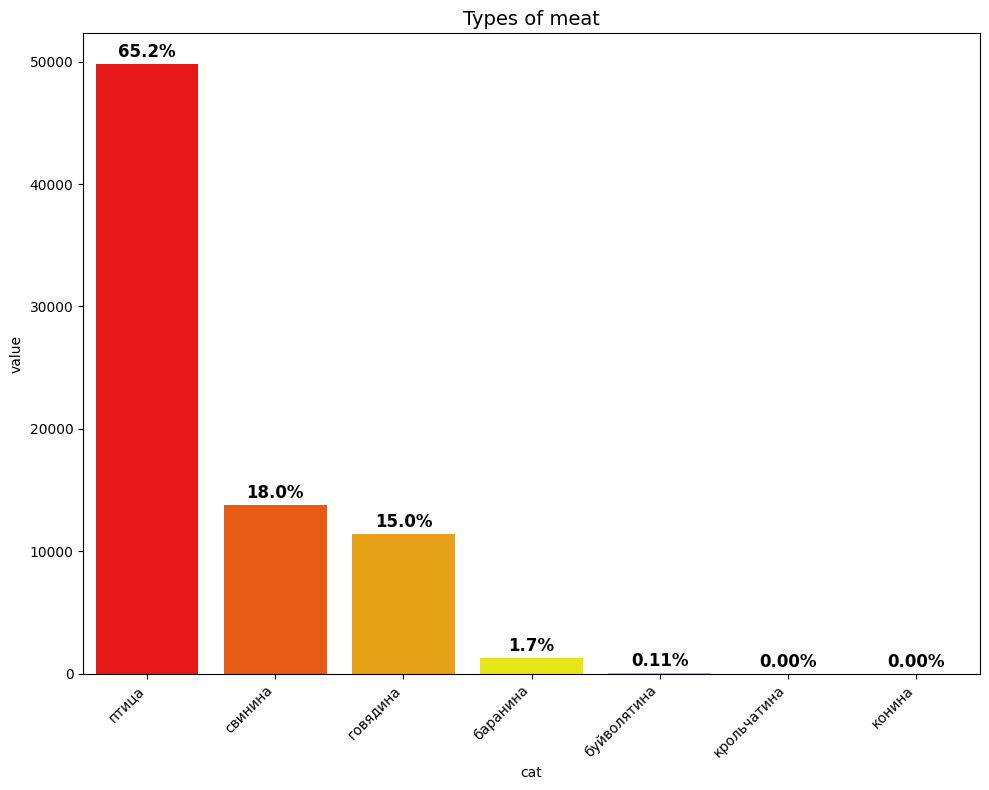

In [27]:
plot_classes_count(meat_types, meat_types.shape[0], 5, "Types of meat", figsize=(10, 8), vertical=True)

Кол-во экземпляров буйволятины, крольчатины и конинны незначительно.

## Чистка

Создадим функцию предобработки датафрейма и подготовки для дальнейших шагов:
1. Создадим проверку на наличие сохранённого обработанного датафрейма
2. Удалим явные дубликаты и присвоим новые индексы
3. Создадим список ограничений - слов, которые могут быть полезны при семантической обработке
4. Удалим лишние символы и знаки из текстов, применяя паттерн для фильтрации исключений
5. Лемматизируем **description** при помощи **pymystem3**

In [28]:
def preprocessing_meat_df(
    df,
    text_columns,
    file_path=os.path.join(datapath, 'lemmatized_processed_meat_dataset_v2.csv')
):
    
    if os.path.exists(file_path):
        print("Обработанный датафрейм существует. Загрузка...")
        processed_df = pd.read_csv(file_path, sep=";", index_col=0)
        return processed_df
    
    print("Обрабатываем датафрейм...")
    
    df["raw_id"] = df.index  
    df = df.drop_duplicates(subset=text_columns)
    df = df.reset_index(drop=True)

    # Создание шаблона для обработки исключений
    words_to_save = ['гр', '6', 'с', 'на', 'со', 'из']  # 1
    exceptions_pattern = r'\b(?:{})\b'.format('|'.join(map(re.escape, words_to_save)))
    pattern = rf'(?ix){exceptions_pattern}|[а-яё]{{3,}}(?:/[а-яё]+)?|[а-яё]+/[а-яё]+'
    
    # Лемматизация с помощью pymystem3
    m = Mystem()
    
    # Разделитель для объединения текстов
    separator = "|||separator|||"
    
    # Обработка каждой текстовой колонки
    for col_name in tqdm(text_columns, desc="Обработка колонок"):
        print(f"Обрабатываем колонку: {col_name}")
        
        # Очистка текстов по паттерну
        df[f"cleaned_{col_name}"] = df[col_name].apply(
            lambda text: ' '.join(re.findall(pattern, text)) if pd.notna(text) and text != "" else ""
        )
        df[f"cleaned_{col_name}"] = df[f"cleaned_{col_name}"].fillna("")
        
        # Лемматизация
        all_texts = separator.join(df[f"cleaned_{col_name}"].tolist())
        print(f"Лемматизация колонки {col_name}...")
        lemmatized_all = m.lemmatize(all_texts.lower())
        lemmatized_text = "".join(lemmatized_all)
        lemmatized_parts = lemmatized_text.split(separator)
        
        # Очистка лемматизированных текстов
        cleaned_lemmatized = []
        for part in tqdm(lemmatized_parts, desc=f"Очистка лемм для {col_name}"):
            cleaned_part = " ".join([lemma.strip() for lemma in part.split() if lemma.strip() and lemma.strip() != '\n'])
            cleaned_lemmatized.append(cleaned_part)
        
        # Присвоение результатов обратно в датафрейм
        df[f"cleaned_{col_name}"] = cleaned_lemmatized[:len(df)]
    
    # Сохранение обработанного датафрейма
    df.to_csv(file_path, sep=';')
    print(f"Датафрейм сохранён в {file_path}")

    return df

In [29]:
df = preprocessing_meat_df(df, ['description', 'product_type'])

Обработанный датафрейм существует. Загрузка...


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67714 entries, 0 to 67713
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   product               67714 non-null  object
 1   description           67714 non-null  object
 2   product_type          67714 non-null  object
 3   meat_type             67714 non-null  object
 4   raw_id                67714 non-null  int64 
 5   cleaned_description   67706 non-null  object
 6   cleaned_product_type  67714 non-null  object
dtypes: int64(1), object(6)
memory usage: 4.1+ MB


In [31]:
df["cleaned_description"] = df["cleaned_description"].fillna("")

## [x] Валидация product

Предположим наличие слов (токенов) в описании, которые относятся к некоторому классу, отличному от размеченного.

## Исправление наименований категорий (если требуется)

Поищем классы, которые являются неявными дубликатами друг к другу

In [32]:
print(f"Категории product: {sorted(df['product'].unique().tolist())}")

Категории product: ['баранина', 'буйволятина', 'говядина', 'гусь', 'индейка', 'конина', 'кролик', 'кура', 'перепел', 'свинина', 'страус', 'телятина', 'утка', 'фазан', 'цесарка', 'цыпленок', 'ягнятина']


In [33]:
print(f"Категории product_type: {sorted(df['product_type'].unique().tolist())}")

Категории product_type: ['12 частей', '6 отрубов', 'азу', 'антрекот', 'аорта', 'ассорти', 'баки', 'балык', 'бедро', 'бескостная', 'бефстроганов', 'бифштекс', 'блочная', 'вымя', 'вырезка', 'глазной мускул', 'голень', 'головы', 'голяшка', 'гребешки', 'грудинка', 'грудка', 'грудной отруб', 'губы', 'гузки', 'гуляш', 'диафрагма', 'длиннейшая мышца', 'железа', 'желудки', 'жилка', 'жир', 'жир (сырец)', 'жир-сырец', 'задние части', 'задняя четвертина', 'калтык', 'карбонад', 'каркас', 'киль', 'кишечник', 'кишка', 'кишки', 'книжка', 'кожа', 'копыта', 'корейка', 'кости', 'костный остаток', 'кострец', 'кость', 'котлетные части (котлета)', 'кровь', 'крыло', 'курдюк', 'лапы', 'легкое', 'лопатка', 'лопаточная часть', 'лопаточно-плечевая часть', 'лопаточно-шейная часть', 'лопаточно-шейный отруб', 'лопаточный отруб', 'лытка', 'маска', 'медальон', 'межсосковая часть', 'микс', 'мозги', 'мука мясокостная', 'мышца', 'мякоть', 'мясо', 'мясо механической обвалки', 'мясокостная мука', 'набор для бульона', 'на

In [34]:
# PRODUCT унификация категорий
df.loc[df["product"] == "свиньи", "product"] = "свинина"

# PRODUCT_TYPE
product_type_mapping = {cat: cat for cat in sorted(df['product_type'].unique().tolist())}

product_type_mapping['спиной отруб'] = 'спинной отруб' 
product_type_mapping['полутиши'] = 'полутуши' 
product_type_mapping['гузка'] = 'гузки' 
product_type_mapping['филе грубки'] = 'филе грудки' 
product_type_mapping['лопаточно-шейный отруб'] = 'шейно-лопаточный отруб'
product_type_mapping['голова'] = 'головы' 
product_type_mapping['желудок'] = 'желудки' 
product_type_mapping['жир-сырец'] = 'жир (сырец)' 

In [35]:
# применение маппинга
df["product_type"] = df["product_type"].map(product_type_mapping)

In [36]:
number_of_others_cats = df[~df['meat_type'].isin(['птица', 'свинина', 'говядина', 'баранина'])].shape[0]
print(f"Количество эксемпляров лежащих за пределами разрубов: {number_of_others_cats}")

Количество эксемпляров лежащих за пределами разрубов: 50


In [37]:
print(
    f"Кол-во классов не размеченные в файлах: {(number_of_others_cats / df.shape[0]):.2%}"
)

Кол-во классов не размеченные в файлах: 0.07%


# Изучение классового баланса столбца **proudct**

In [38]:
# PRODUCT
prods = df["product"].value_counts()

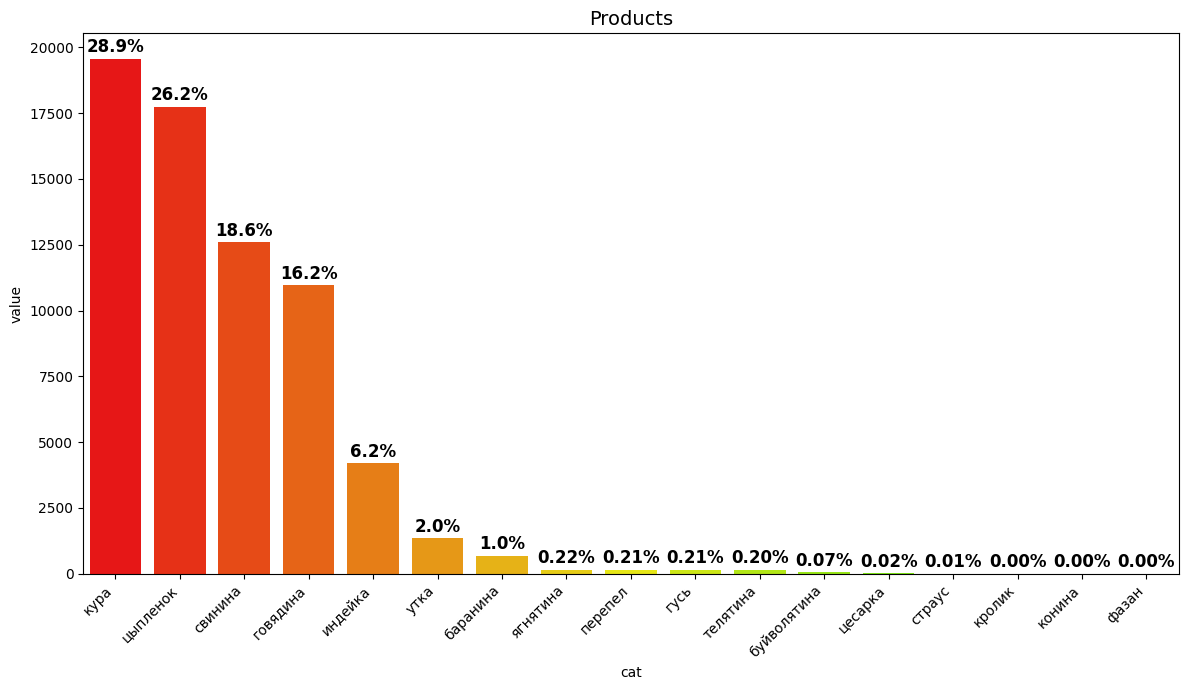

In [39]:
plot_classes_count(prods, prods.shape[0], 5, "Products", figsize=(12, 7), vertical=True)

# Изучение классового баланса столбца **proudct_type**

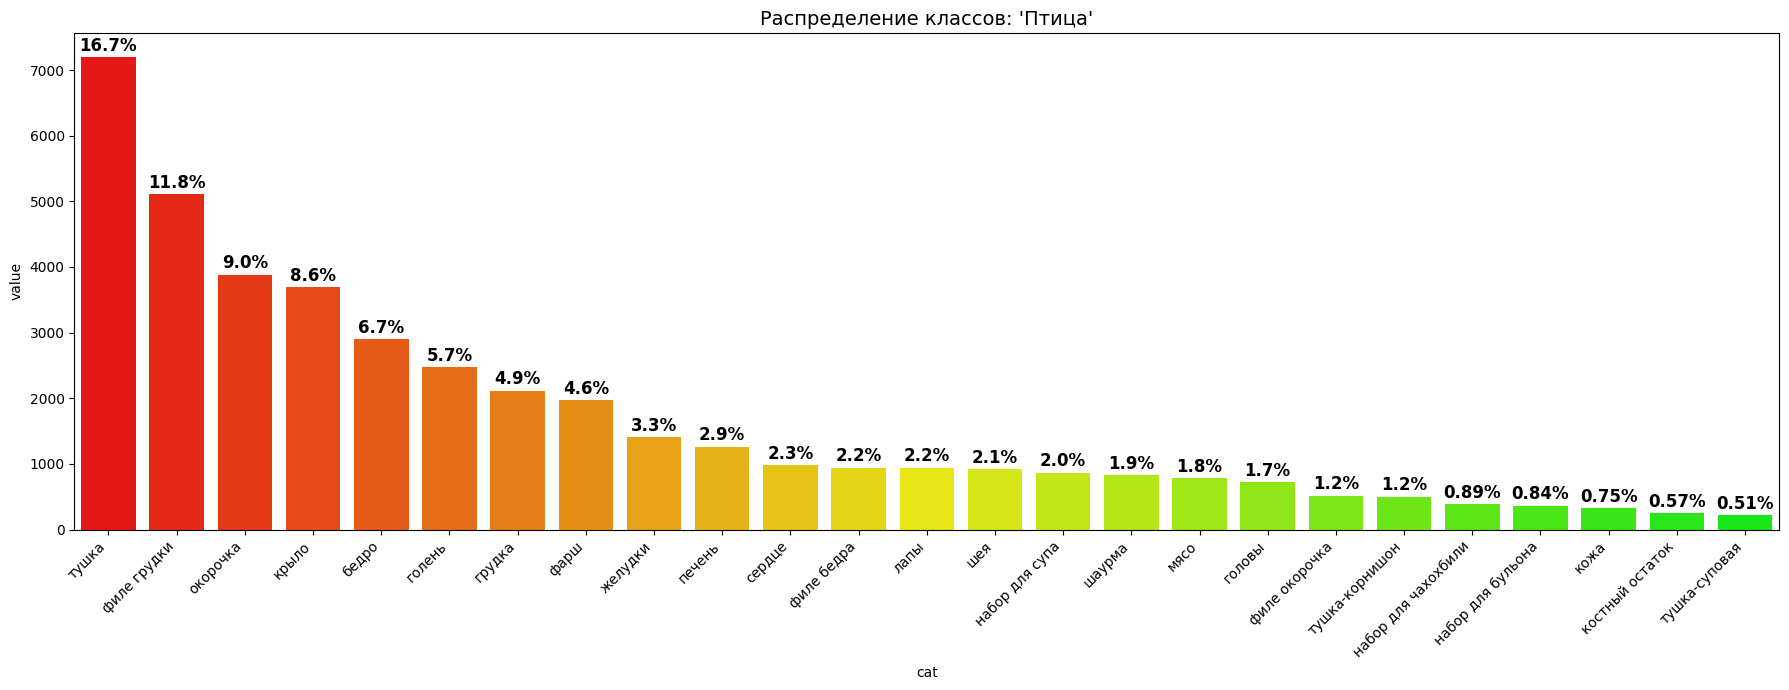

In [40]:
# птица
num_of_classes_bird = df[df['meat_type'] == 'птица']['product_type'].value_counts()

plot_classes_count(
    num_of_classes_bird,
    num_to_plot=25,
    vertical=True,
    figsize=(18, 7),
    title="Распределение классов: 'Птица'"
)

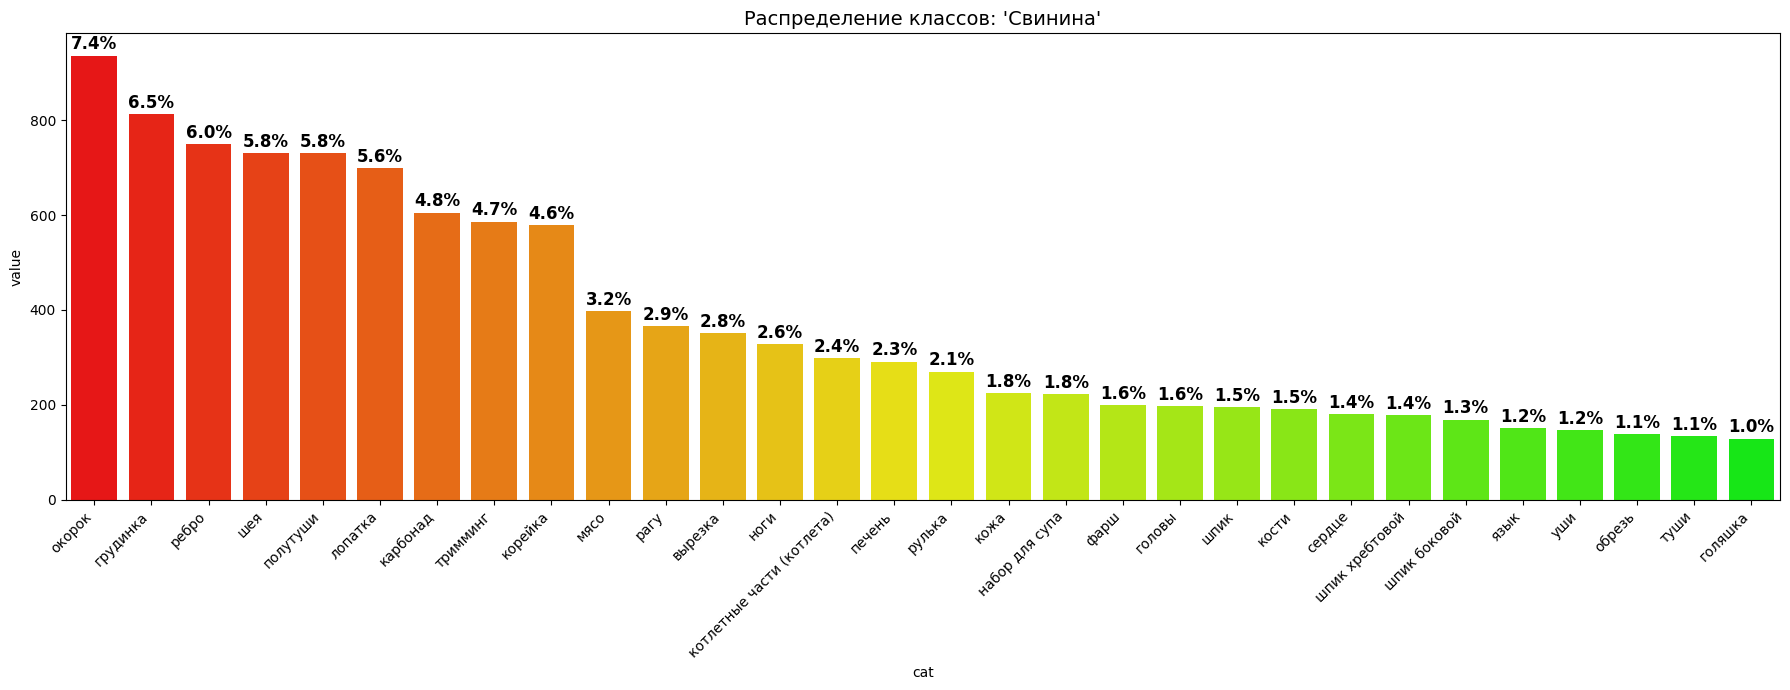

In [41]:
# свинина
num_of_classes_pork = df[df['meat_type'] == 'свинина']['product_type'].value_counts()

plot_classes_count(
    num_of_classes_pork,
    num_to_plot=30,
    vertical=True,
    figsize=(18, 7),
    title="Распределение классов: 'Свинина'"
)

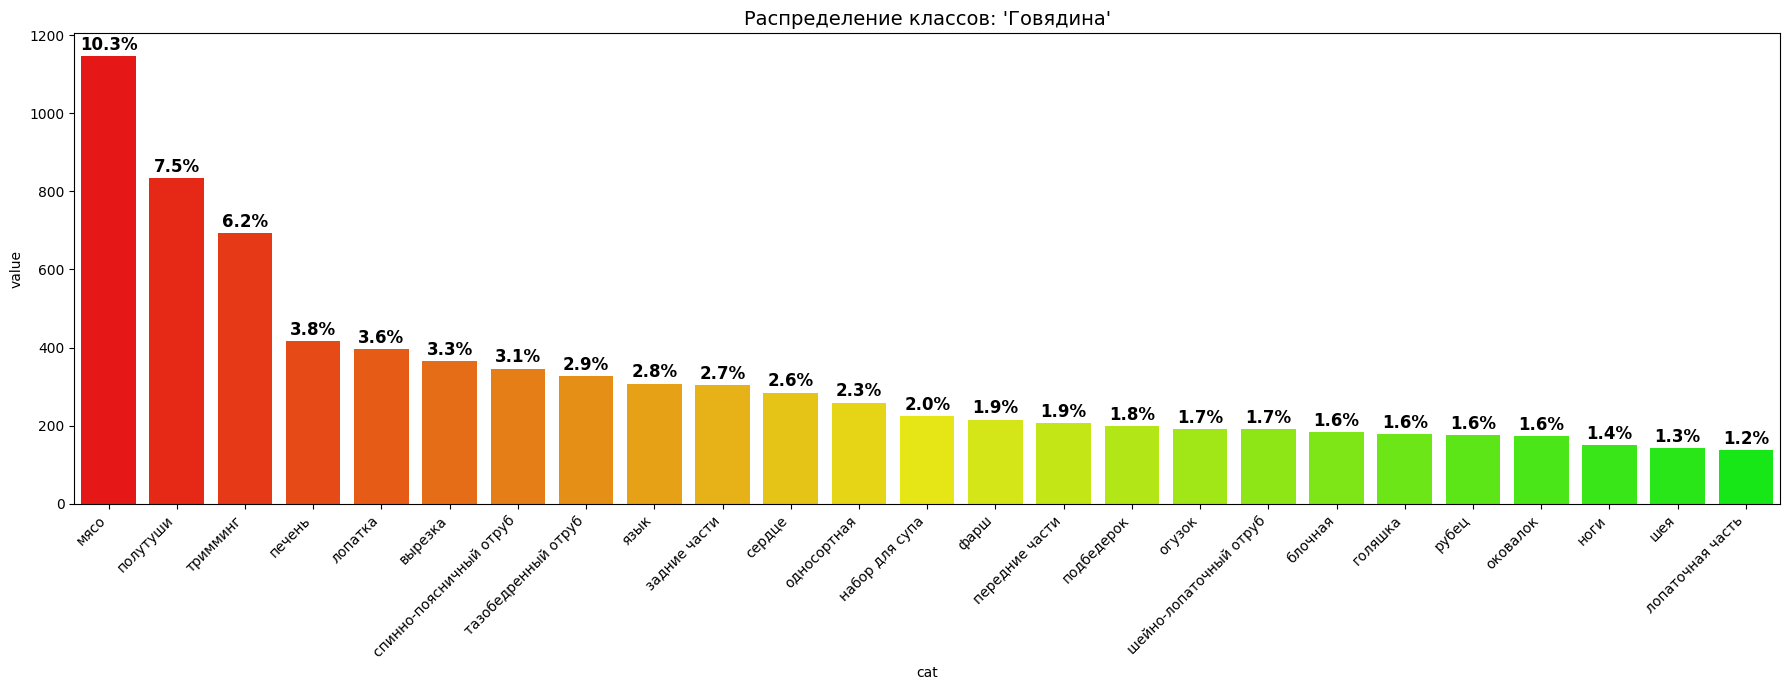

In [42]:
# говядина
num_of_classes_beef = df[df['meat_type'] == 'говядина']['product_type'].value_counts()

plot_classes_count(
    num_of_classes_beef,
    num_to_plot=25,
    vertical=True,
    figsize=(18, 7),
    title="Распределение классов: 'Говядина'"
)

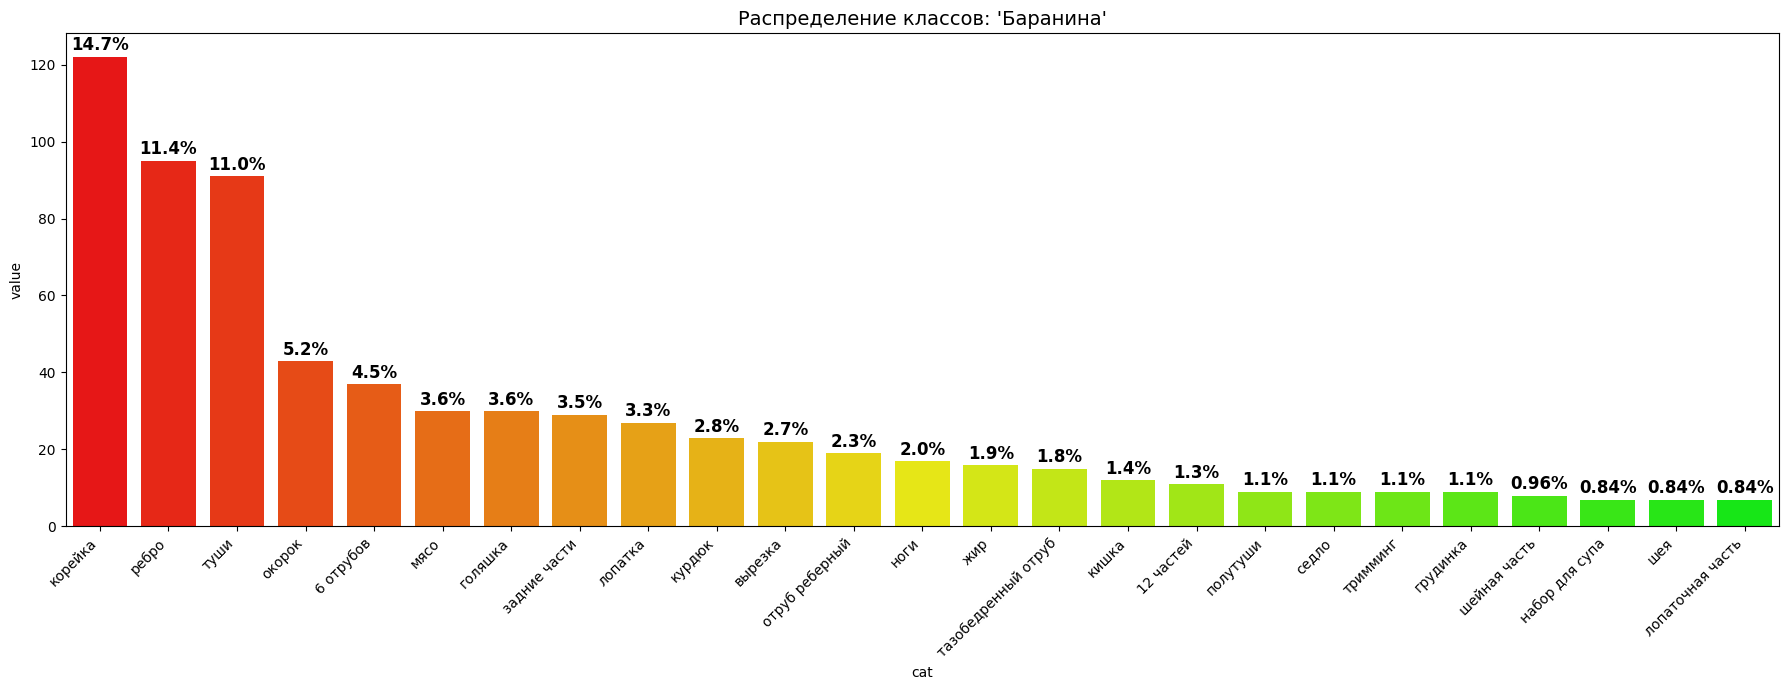

In [43]:
# баранина
num_of_classes_mutton = df[df['meat_type'] == 'баранина']['product_type'].value_counts()

plot_classes_count(
    num_of_classes_mutton,
    num_to_plot=25,
    vertical=True,
    figsize=(18, 7),
    title="Распределение классов: 'Баранина'"
)

Среди **основных проблем:** неявные дубликаты в классах, не все классы распознаются верно.

**Дополнительная проверка**

In [44]:
for cls in df[df['meat_type'] == 'птица']['product_type'].unique():
    if cls not in bird['value'].unique():
        print(cls)

In [45]:
for cls in df[df['meat_type'] == 'свинина']['product_type'].unique():
    if cls not in pork['value'].unique():
        print(cls)

шейно-лопаточный отруб


In [46]:
# в разрубах есть категория 'кости', заменяем
df.loc[(df['meat_type'] == 'свинина') & (df['product_type'] == 'кость'), 'product_type'] = 'кости'

# в разрубах другой порядок слов, заменяем на лопаточно-шейный отруб
df.loc[(df['meat_type'] == 'свинина') & (df['product_type'] == 'шейно-лопаточный отруб'), 'product_type'] = 'лопаточно-шейный отруб'

In [47]:
for cls in df[df['meat_type'] == 'говядина']['product_type'].unique():
    if cls not in beef['value'].unique():
        print(cls)

односортная


In [48]:
for cls in df[df['meat_type'] == 'баранина']['product_type'].unique():
    if cls not in mutton['value'].unique():
        print(cls)

# Валидация product_type

In [49]:
df.reset_index(drop=True, inplace=True)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67714 entries, 0 to 67713
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   product               67714 non-null  object
 1   description           67714 non-null  object
 2   product_type          67714 non-null  object
 3   meat_type             67714 non-null  object
 4   raw_id                67714 non-null  int64 
 5   cleaned_description   67714 non-null  object
 6   cleaned_product_type  67714 non-null  object
dtypes: int64(1), object(6)
memory usage: 3.6+ MB


In [51]:
print(f"После предварительной обработки доля объектов от изаначатльного датафрейма составляет: {df.shape[0] / df_init_shape[0]:.2%}")

После предварительной обработки доля объектов от изаначатльного датафрейма составляет: 88.63%


Были удалены дубликаты и пустые строки, полученные в результате лемматизации.

В текстах описаний содерижтся множество слов, которые не несут полезной информации для признака `product_type` и тем самым будут создавать "шумовые" n-граммы. Создадим список `stop_words` для удаления этих слов из объекта векторизатора текстов (TF-IDF).

In [52]:
# df с подсчётом слов в датафрейме
words = pd.DataFrame(
        data=Counter(" ".join(df['cleaned_description'].values).split()).items(), 
        columns=['word', 'count']
    )

In [53]:
# # анализ и добавление стоп-слов производился вручную с помощью следующих строк
# words = words[words['word'].apply(lambda x: x not in stop_words)].sort_values(by='count', ascending=False)
# words.to_excel('analyze_and_get_stopwords.xlsx')

## Автоматический валидатор текстовых меток

Далее будет описан класс для автоматической валидации меток текстов. 

Алгоритм работы:
- Для каждого типа мяса создаются отдельные статистические пороги
- Запись считается валидной, если проходит оба критерия (или дополнительные) критерии
- Для невалидных записей генерируются рекомендации на основе центроидов валидных групп

In [54]:
class LabelValidator:
    """
    Класс для валидации соответствия описаний товаров их категориям
    с поддержкой изоляции по типам мяса и генерации рекомендаций.
    """
    
    _EMBEDDING_MODEL_ALIASES = {
        # короткие алиасы => полный путь модели HuggingFace
        'paraphrase': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
        'paraphrase-mpnet': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
        'frida': 'ai-forever/FRIDA'
    }

    @staticmethod
    def _resolve_embedding_model(model_name: str) -> str:
        """Преобразует короткое имя модели в полный HF id (если задан алиас)."""
        return LabelValidator._EMBEDDING_MODEL_ALIASES.get(model_name.lower(), model_name)

    def __init__(self, stop_words_file, ngram_range=(1, 3), max_features=10000, 
                 token_pattern=r'\b[а-яё]+\b', semantic_threshold=0.3,
                 relaxed_similarity_threshold=0.2, relaxed_ngram_overlap_threshold=0.3,
                 vectorizer_type='tfidf', embedding_model='sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
                 embeddings_path=None, use_gpu=True, n_jobs=-1):
        """Инициализация валидатора."""
        embedding_model = LabelValidator._resolve_embedding_model(embedding_model)
        self.vectorizer_type = vectorizer_type
        self.embedding_model = embedding_model
        self.embeddings_path = embeddings_path
        self.use_gpu = use_gpu
        self.ngram_range = ngram_range
        self.max_features = max_features
        self.token_pattern = token_pattern
        self.semantic_threshold = semantic_threshold
        self.relaxed_similarity_threshold = relaxed_similarity_threshold
        self.relaxed_ngram_overlap_threshold = relaxed_ngram_overlap_threshold
        self.n_jobs = n_jobs
        
        self._load_stop_words(stop_words_file)
        self._init_vectorizer()

        self.is_fitted = False
        self.vector_matrix = None
        self.product_type_vectors = {}
        
        self._print_init_summary()

    def _load_stop_words(self, stop_words_file):
        """Загружает стоп-слова из файла."""
        try:
            with open(stop_words_file, "r", encoding="utf-8") as f:
                self.stop_words = json.load(f)
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"⚠️ Ошибка при загрузке стоп-слов: {e}. Использую пустой список.")
            self.stop_words = []

    def _init_vectorizer(self):
        """Инициализирует векторизатор или модель эмбеддингов."""
        if self.vectorizer_type == 'tfidf':
            self.vectorizer = TfidfVectorizer(
                ngram_range=self.ngram_range,
                max_features=self.max_features,
                stop_words=self.stop_words,
                lowercase=True,
                token_pattern=self.token_pattern
            )
            self.model = None
        elif self.vectorizer_type == 'embedding':
            self.device = 'cuda' if torch.cuda.is_available() and self.use_gpu else 'cpu'
            self.model = SentenceTransformer(self.embedding_model, device=self.device)
            self.vectorizer = None
        elif self.vectorizer_type == 'frida':
            self.device = 'cuda' if torch.cuda.is_available() and self.use_gpu else 'cpu'
            if self.embedding_model == LabelValidator._EMBEDDING_MODEL_ALIASES['paraphrase']:
                self.embedding_model = LabelValidator._EMBEDDING_MODEL_ALIASES['frida']
            self.model = SentenceTransformer(self.embedding_model, device=self.device)
            self.vectorizer = None
        else:
            raise ValueError("Неверный тип векторизатора. Используйте 'tfidf', 'embedding' или 'frida'.")

    def _print_init_summary(self):
        """Выводит сводную информацию после инициализации."""
        print(f"🔧 LabelValidator инициализирован:")
        print(f"  • Тип векторизатора: {self.vectorizer_type}")
        if self.vectorizer_type == 'tfidf':
            print(f"  • N-граммы: {self.ngram_range}")
            print(f"  • Макс. признаков: {self.max_features}")
        else:
            print(f"  • Модель эмбеддингов: {self.embedding_model} на '{self.device}'")
        print(f"  • Семантический порог: {self.semantic_threshold}")
        jobs_info = "all available" if self.n_jobs == -1 else str(self.n_jobs)
        print(f"  • Параллельных процессов: {jobs_info} (CPU cores: {cpu_count()})")

    def fit(self, descriptions):
        """Обучает векторизатор или генерирует эмбеддинги."""
        clean_descriptions = pd.Series(descriptions).fillna('').astype(str)
        
        if self.vectorizer_type == 'tfidf':
            self._fit_tfidf(clean_descriptions)
        else:
            self._fit_embedding(clean_descriptions)
            
        self.is_fitted = True
        print(f"Векторизатор обучен на {len(descriptions)} записях.")

    def _fit_tfidf(self, clean_descriptions):
        """Обучение TF-IDF."""
        print("Обучаю TF-IDF и векторизую тексты...")
        self.vector_matrix = self.vectorizer.fit_transform(
            tqdm(clean_descriptions, desc="Обработка текстов")
        )
        print(f"Размерность TF-IDF матрицы: {self.vector_matrix.shape}")

    def _fit_embedding(self, clean_descriptions):
        """Генерация или загрузка эмбеддингов."""
        if self.embeddings_path and os.path.exists(self.embeddings_path):
            print(f"Загружаю готовые эмбеддинги из файла: {self.embeddings_path}")
            self.vector_matrix = np.load(self.embeddings_path)
        else:
            print(f"Генерирую эмбеддинги для {len(clean_descriptions)} описаний...")
            self.vector_matrix = self.model.encode(
                clean_descriptions.tolist(), 
                show_progress_bar=True,
                convert_to_tensor=False
            )
            if self.embeddings_path:
                self._save_embeddings()
        print(f"Размерность матрицы эмбеддингов: {self.vector_matrix.shape}")
    
    def _save_embeddings(self):
        """Сохраняет эмбеддинги в файл."""
        try:
            if (dir_name := os.path.dirname(self.embeddings_path)):
                os.makedirs(dir_name, exist_ok=True)
            print(f"💾 Сохраняю эмбеддинги в файл: {self.embeddings_path}")
            np.save(self.embeddings_path, self.vector_matrix)
        except Exception as e:
            print(f"⚠️ Не удалось сохранить эмбеддинги: {e}")

    def _get_similarity_scores_for_group(self, group, df_index_to_vector_pos):
        """Возвращает оценки сходства для группы в зависимости от типа векторизатора."""
        if self.vectorizer_type == 'tfidf':
            return self._get_tfidf_similarity_for_group(group)
        else:
            return self._get_embedding_similarity_for_group(group, df_index_to_vector_pos)

    def _get_tfidf_similarity_for_group(self, group):
        """Возвращает оценки сходства для группы (TF-IDF)."""
        similarity_scores = []
        for _, row in group.iterrows():
            desc = str(row.get('cleaned_description', ''))
            ptype = str(row.get('cleaned_product_type', ''))
            if desc and ptype:
                metrics = self._compute_tfidf_confidence(desc, ptype)
                similarity_scores.append(metrics['main_similarity'])
        return similarity_scores

    def _get_embedding_similarity_for_group(self, group, df_index_to_vector_pos):
        """Возвращает оценки сходства для группы (Embeddings)."""
        product_type = group['product_type'].iloc[0]
        ptype_vector = self.product_type_vectors.get(product_type)
        if ptype_vector is None:
            return []
        
        ptype_vector = ptype_vector.reshape(1, -1)
        group_positions = [df_index_to_vector_pos[i] for i in group.index]
        desc_vectors = self.vector_matrix[group_positions]
        
        similarities = cosine_similarity(desc_vectors, ptype_vector)
        return similarities.flatten().tolist()

    def _get_semantic_metrics(self, row, idx, df_index_to_vector_pos):
        """Возвращает семантические метрики в зависимости от типа векторизатора."""
        desc = str(row.get('cleaned_description', ''))
        ptype = str(row.get('cleaned_product_type', ''))

        if not desc or not ptype:
            return {'confidence_score': 0.0, 'main_similarity': 0.0}

        if self.vectorizer_type == 'tfidf':
            return self._compute_tfidf_confidence(desc, ptype)
        else:
            return self._compute_embedding_confidence(idx, row, df_index_to_vector_pos)

    def _compute_tfidf_confidence(self, description, product_type):
        """Вычисляет семантическую уверенность для TF-IDF."""
        try:
            desc_vector = self.vectorizer.transform([description])
            type_vector = self.vectorizer.transform([product_type])
            main_similarity = cosine_similarity(desc_vector, type_vector)[0][0]
            
            desc_ngrams = self._extract_ngrams(description)
            type_ngrams = self._extract_ngrams(product_type)
            
            common_ngrams = set(desc_ngrams) & set(type_ngrams)
            ngram_overlap_ratio = len(common_ngrams) / max(len(type_ngrams), 1)
            
            partial_matches = sum(1 for d_ng in desc_ngrams for t_ng in type_ngrams if d_ng != t_ng and (d_ng in t_ng or t_ng in d_ng))
            partial_match_ratio = partial_matches / max(len(type_ngrams), 1)
            
            confidence_score = main_similarity * 0.6 + ngram_overlap_ratio * 0.3 + partial_match_ratio * 0.1
            
            return {
                'main_similarity': float(main_similarity),
                'ngram_overlap_ratio': float(ngram_overlap_ratio),
                'partial_match_ratio': float(partial_match_ratio),
                'confidence_score': float(confidence_score),
                'common_ngrams_count': len(common_ngrams)
            }
        except Exception as e:
            print(f"⚠️ Ошибка TF-IDF confidence для '{description[:30]}...': {e}")
            return {'main_similarity': 0.0, 'ngram_overlap_ratio': 0.0, 'partial_match_ratio': 0.0, 'confidence_score': 0.0, 'common_ngrams_count': 0}

    def _compute_embedding_confidence(self, idx, row, df_index_to_vector_pos):
        """Вычисляет семантическую уверенность для Embeddings."""
        desc_vector = self.vector_matrix[df_index_to_vector_pos[idx]].reshape(1, -1)
        ptype_vector = self.product_type_vectors.get(row['cleaned_product_type'])
        
        if ptype_vector is None:
            main_similarity = 0.0
        else:
            main_similarity = cosine_similarity(desc_vector, ptype_vector.reshape(1, -1))[0][0]
            
        return {
            'main_similarity': float(main_similarity),
            'confidence_score': float(main_similarity),
            'ngram_overlap_ratio': 0.0, 'partial_match_ratio': 0.0, 'common_ngrams_count': 0
        }

    def _extract_ngrams(self, text):
        """Извлекает n-граммы из текста, используя обученный TF-IDF векторизатор."""
        if self.vectorizer_type != 'tfidf' or not self.is_fitted:
            return []
        try:
            tfidf_result = self.vectorizer.transform([text.strip()])
            feature_names = self.vectorizer.get_feature_names_out()
            return [feature_names[i] for i in tfidf_result.indices]
        except Exception:
            return []

    @staticmethod
    def _compute_statistical_threshold(scores):
        """Вычисляет статистический порог на основе Z-score."""
        if not scores or len(scores) < 2:
            return 0.1
        
        scores_arr = np.array(scores)
        median = np.median(scores_arr)
        mad = np.median(np.abs(scores_arr - median))
        
        if mad > 0:
            return max(median - 2.5 * mad, 0.1)
        else:
            mean = np.mean(scores_arr)
            std = np.std(scores_arr)
            return max(mean - 1.5 * std, 0.1)

    def complex_validation(self, df: pd.DataFrame) -> pd.DataFrame:
        """Выполняет комплексную двухэтапную валидацию."""
        if not self.is_fitted:
            raise ValueError("Векторизатор не обучен! Вызовите метод fit() сначала.")
        
        print("Начинаю валидацию...")
        validated_df = df.copy()
        df_index_to_vector_pos = {idx: pos for pos, idx in enumerate(df.index)}

        if self.vectorizer_type == 'embedding':
            self._precompute_product_type_vectors(validated_df)
        self._initialize_validation_columns(validated_df)
        for meat_type in validated_df['meat_type'].dropna().unique():
            print(f"\nОбрабатываю тип мяса: {meat_type}")
            meat_mask = validated_df['meat_type'] == meat_type
            meat_df = validated_df[meat_mask]
            group_statistics = self._compute_all_group_statistics(meat_df, df_index_to_vector_pos)
            self._validate_rows_in_parallel(validated_df, meat_df, group_statistics, meat_type, df_index_to_vector_pos)

        print("\n✅ Валидация завершена!")
        return validated_df

    def _precompute_product_type_vectors(self, df):
        """Предварительно вычисляет эмбеддинги для всех уникальных категорий."""
        all_product_types = df['cleaned_product_type'].dropna().unique()
        print(f"🧬 Предварительно вычисляю эмбеддинги для {len(all_product_types)} уникальных категорий...")
        
        ptype_vectors_list = self.model.encode(
            all_product_types, show_progress_bar=True, convert_to_tensor=False
        )
        self.product_type_vectors = dict(zip(all_product_types, ptype_vectors_list))

    def _initialize_validation_columns(self, df):
        """Инициализирует колонки для результатов валидации."""
        new_columns = {
            'confidence_score': 0.0, 'ngram_overlap_ratio': 0.0, 'partial_match_ratio': 0.0,
            'statistical_threshold': 0.0, 'is_statistical_valid': False, 'is_semantic_valid': False,
            'validation_confidence': 0.0, 'validation_method': 'unknown', 'is_valid': False
        }
        for col, default_val in new_columns.items():
            df[col] = default_val

    def _compute_all_group_statistics(self, meat_df, df_index_to_vector_pos):
        """Вычисляет статистику для всех групп в DataFrame."""
        groups = list(meat_df.groupby('product_type'))
        print(f"Вычисляю статистику для {len(groups)} категорий...")

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._compute_single_group_stats)(group, df_index_to_vector_pos)
            for group in tqdm(groups, desc="Расчет статистики групп")
        )
        return {pt: stats for pt, stats in filter(None, results)}

    def _compute_single_group_stats(self, group_tuple, df_index_to_vector_pos):
        """Вычисляет статистику для одной группы."""
        product_type, group = group_tuple
        if len(group) < 2:
            return None
        
        similarity_scores = self._get_similarity_scores_for_group(group, df_index_to_vector_pos)
        if not similarity_scores:
            return None
        
        threshold = self._compute_statistical_threshold(similarity_scores)
        return product_type, {'z_threshold': threshold}

    def _validate_rows_in_parallel(self, main_df, meat_df, group_stats, meat_type, df_index_to_vector_pos):
        """Запускает валидацию строк в параллельном режиме."""
        print(f"Применяю валидацию для {len(meat_df)} записей...")
        rows_to_process = list(meat_df.iterrows())
        
        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._validate_single_row)(row, group_stats, meat_type, df_index_to_vector_pos)
            for row in tqdm(rows_to_process, desc=f"Валидация {meat_type}")
        )
        
        for idx, res_dict in results:
            for col, val in res_dict.items():
                main_df.loc[idx, col] = val
    
    def _validate_single_row(self, row_tuple, group_statistics, meat_type, df_index_to_vector_pos):
        """Выполняет логику валидации для одной строки."""
        idx, row = row_tuple
        product_type = row.get('product_type', '')

        if pd.isna(product_type) or not str(product_type).strip():
            return idx, {'validation_method': 'empty_label'}
        
        semantic_metrics = self._get_semantic_metrics(row, idx, df_index_to_vector_pos)
        result = semantic_metrics.copy()

        if product_type in group_statistics:
            stats = group_statistics[product_type]
            stat_threshold = stats.get('z_threshold', 0.1)
            
            current_similarity = result.get('main_similarity', 0.0)
            confidence_score = result.get('confidence_score', 0.0)

            is_stat_valid = current_similarity >= stat_threshold
            is_sem_valid = confidence_score >= self.semantic_threshold
            
            result.update({
                'statistical_threshold': stat_threshold,
                'is_statistical_valid': is_stat_valid,
                'is_semantic_valid': is_sem_valid,
            })

            is_relaxed_valid = (current_similarity >= self.relaxed_similarity_threshold and
                                result.get('ngram_overlap_ratio', 0.0) >= self.relaxed_ngram_overlap_threshold)

            if is_stat_valid and is_sem_valid:
                result.update({'is_valid': True, 'validation_method': f'multi_criteria_passed_{meat_type}', 'validation_confidence': 0.9})
            elif is_relaxed_valid:
                result.update({'is_valid': True, 'validation_method': f'relaxed_criteria_{meat_type}', 'validation_confidence': 0.6})
            else:
                result.update({'is_valid': False, 'validation_method': f'criteria_failed_{meat_type}', 'validation_confidence': 0.2})
        else:
            # Логика для групп без достаточной статистики
            is_sem_valid = result.get('confidence_score', 0.0) >= 0.4
            result.update({
                'is_valid': is_sem_valid,
                'validation_method': f'semantic_only_{meat_type}',
                'validation_confidence': result.get('confidence_score', 0.0)
            })
            
        return idx, result

    def recommend_labels(self, df, n_recommendations=3):
        """Рекомендует новые лейблы для невалидных записей."""
        if not self.is_fitted:
            raise ValueError("Векторизатор не обучен! Вызовите метод fit() сначала.")
            
        print("\n" + "="*50)
        print("🚀 ГЕНЕРАЦИЯ РЕКОМЕНДАЦИЙ ЛЕЙБЛОВ")
        print("="*50)
        
        reco_df = df.copy()
        self._initialize_recommendation_columns(reco_df)
        
        invalid_records = reco_df[reco_df['is_valid'] == False]
        if invalid_records.empty:
            print("✅ Все записи валидны, рекомендации не требуются.")
            return reco_df
            
        print(f"📊 Найдено {len(invalid_records):,} невалидных записей для анализа.")
        df_index_to_vector_pos = {idx: pos for pos, idx in enumerate(reco_df.index)}
        
        # Обработка по типам мяса
        for meat_type in reco_df['meat_type'].dropna().unique():
            print(f"\nАнализирую тип мяса: {meat_type}")
            self._recommend_for_meat_type(reco_df, meat_type, df_index_to_vector_pos)

        total_recommended = len(reco_df[reco_df['suggestion_reason'].str.contains('alternative')])
        print(f"\n✅ Генерация рекомендаций завершена. Создано {total_recommended} новых рекомендаций.")
        return reco_df

    def _initialize_recommendation_columns(self, df):
        """Инициализирует колонки для рекомендаций."""
        df['suggestion_product_type'] = np.where(df['is_valid'], df['product_type'], '')
        df['suggestion_confidence'] = df['is_valid'].astype(float)
        df['suggestion_reason'] = np.where(df['is_valid'], 'original_valid', 'needs_recommendation')
        df['similar_records_count'] = 0

    def _recommend_for_meat_type(self, df, meat_type, df_index_to_vector_pos):
        """Генерирует рекомендации для одного типа мяса."""
        meat_mask = df['meat_type'] == meat_type
        valid_records = df[meat_mask & df['is_valid']]
        invalid_records = df[meat_mask & ~df['is_valid']]

        if invalid_records.empty:
            print(f"  • Все записи для '{meat_type}' валидны.")
            return

        if valid_records.empty:
            print(f"  ⚠️ Нет валидных записей для '{meat_type}', невозможно сгенерировать рекомендации.")
            df.loc[invalid_records.index, 'suggestion_reason'] = f'no_valid_examples_{meat_type}'
            return

        print(f"  • Найдено {len(invalid_records)} невалидных и {len(valid_records)} валидных записей.")
        
        # Создание центроидов для валидных групп
        group_centroids = self._create_group_centroids(valid_records, df_index_to_vector_pos)

        if not group_centroids:
            print(f"  ⚠️ Недостаточно данных для создания эталонных групп в '{meat_type}'.")
            df.loc[invalid_records.index, 'suggestion_reason'] = f'insufficient_groups_{meat_type}'
            return

        print(f"  • Создано {len(group_centroids)} эталонных групп.")

        # Генерация рекомендаций
        for idx, row in tqdm(invalid_records.iterrows(), total=len(invalid_records), desc=f"Рекомендации для {meat_type}"):
            recommendation = self._find_best_recommendation(row, group_centroids, df_index_to_vector_pos)
            df.loc[idx, 'suggestion_product_type'] = recommendation['product_type']
            df.loc[idx, 'suggestion_confidence'] = recommendation['similarity']
            df.loc[idx, 'suggestion_reason'] = recommendation['reason']
            df.loc[idx, 'similar_records_count'] = recommendation['count']

    def _create_group_centroids(self, valid_df, df_index_to_vector_pos):
        """Создает центроиды векторов для каждой валидной группы."""
        centroids = {}
        for product_type, group in valid_df.groupby('product_type'):
            if len(group) < 2:
                continue
                
            group_positions = [df_index_to_vector_pos[i] for i in group.index]
            group_vectors = self.vector_matrix[group_positions]
            
            centroid_vec = np.mean(group_vectors.toarray() if self.vectorizer_type == 'tfidf' else group_vectors, axis=0)
            if self.vectorizer_type == 'embedding':
                norm = np.linalg.norm(centroid_vec)
                if norm > 0:
                    centroid_vec /= norm
            
            centroids[product_type] = {'centroid': centroid_vec, 'group_size': len(group)}
        return centroids

    def _find_best_recommendation(self, row, group_centroids, df_index_to_vector_pos):
        """Находит лучшую рекомендацию для одной невалидной записи."""
        idx = row.name
        vector_pos = df_index_to_vector_pos[idx]
        
        current_vector = self.vector_matrix[vector_pos].reshape(1, -1)
        if self.vectorizer_type == 'tfidf':
            current_vector = current_vector.toarray()

        similarities = []
        for ptype, info in group_centroids.items():
            if ptype == row['product_type']: continue
            
            sim = cosine_similarity(current_vector, info['centroid'].reshape(1, -1))[0][0]
            similarities.append({'ptype': ptype, 'sim': sim, 'size': info['group_size']})
        
        if not similarities:
            return {'product_type': 'no_alternative_categories', 'similarity': 0, 'reason': 'no_alternatives', 'count': 0}
            
        similarities.sort(key=lambda x: x['sim'], reverse=True)
        best_match = similarities[0]

        if best_match['sim'] > 0.3:
            reason = f'alternative_{best_match["size"]}_examples'
        elif best_match['sim'] > 0.2:
            reason = f'weak_alternative_{best_match["size"]}_examples'
        else:
            return {'product_type': 'low_similarity_alternatives', 'similarity': best_match['sim'], 'reason': 'low_similarity', 'count': 0}

        return {'product_type': best_match['ptype'], 'similarity': best_match['sim'], 'reason': reason, 'count': best_match['size']}

    def validate(self, df, save_results=True, filename_prefix="validation_results"):
        """Основной метод для выполнения полной валидации и генерации рекомендаций."""
        results_filename = f"{filename_prefix}.csv"
        results_filepath = os.path.join(datapath, results_filename)
        if os.path.exists(results_filepath):
            print(f"📂 Найден существующий файл с результатами: {results_filepath}")
            try:
                print("📥 Загружаю результаты из файла...")
                final_results = pd.read_csv(results_filepath, encoding='utf-8-sig')
                print(f"✅ Результаты успешно загружены! Загружено {len(final_results)} записей.")
                return final_results
            except Exception as e:
                print(f"⚠️ Ошибка при загрузке файла: {e}")
                print("🔄 Запускаю валидацию заново...")
        
        print("\n" + "=" * 50)
        print("| ЗАПУСК ПОЛНОЙ ВАЛИДАЦИИ ЧЕРЕЗ LabelValidator")
        print("=" * 50)
        
        start_time = time.time()
        
        # Этап 1: Валидация
        validation_results = self.complex_validation(df)
        
        # Этап 2: Рекомендации
        final_results = self.recommend_labels(validation_results)
        
        # Этап 3: Анализ и сохранение
        self.print_validation_summary(final_results)
        
        if save_results:
            self.save_results(final_results, filename_prefix)
        
        end_time = time.time()
        print(f"\n🎉 ВАЛИДАЦИЯ ЗАВЕРШЕНА! Время выполнения: {end_time - start_time:.2f} сек.")
        return final_results

    def print_validation_summary(self, df):
        """Выводит краткий отчет по результатам валидации."""
        print("\n" + "="*50)
        print("ОТЧЕТ ПО ВАЛИДАЦИИ")
        print("="*50)
        
        total = len(df)
        invalid_total = len(df[~df['is_valid']])
        print(f"📋 Общая доля невалидных записей: {invalid_total/total*100:.1f}% ({invalid_total:,} из {total:,})")
        
        print("\nСТАТИСТИКА ПО ТИПАМ МЯСА:")
        stats = df.groupby('meat_type')['is_valid'].agg(total='count', invalid=lambda x: (~x).sum())
        stats['invalid_percent'] = (stats['invalid'] / stats['total'] * 100)
        print(stats.to_string(formatters={'invalid_percent': '{:.1f}%'.format}))
        
    def save_results(self, df, filename_prefix="validation_results"):
        """Сохраняет DataFrame в CSV."""
        output_filename = f"{filename_prefix}.csv"
        full_path = os.path.join(datapath, output_filename)
        try:
            print(f"\n💾 Сохраняю результаты в: {full_path}")
            df.to_csv(full_path, index=False, encoding='utf-8-sig')
            print("✅ Результаты сохранены!")
        except Exception as e:
            print(f"⚠️ Ошибка при сохранении файла: {e}")

In [55]:
STOPWORDS_PATH = os.path.join(datapath, 'stopwords.json')

validator = LabelValidator(
    stop_words_file=STOPWORDS_PATH,
    vectorizer_type='tfidf',
    semantic_threshold=0.3,
    ngram_range=(1, 2),
    max_features=500
)

🔧 LabelValidator инициализирован:
  • Тип векторизатора: tfidf
  • N-граммы: (1, 2)
  • Макс. признаков: 500
  • Семантический порог: 0.3
  • Параллельных процессов: all available (CPU cores: 12)


In [56]:
validator.fit(df["cleaned_description"])

Обучаю TF-IDF и векторизую тексты...


Обработка текстов:   0%|          | 0/67714 [00:00<?, ?it/s]c:\Users\dcba5\projects\inline\ai\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['б', 'в', 'валом', 'г', 'инд', 'к', 'кгп', 'мк', 'н', 'п', 'пэта', 'саузгинский', 'т', 'усад', 'ф', 'цвета', 'шт', 'эта', 'ящик'] not in stop_words.
  warnings.warn(
Обработка текстов: 100%|██████████| 67714/67714 [00:00<00:00, 215441.02it/s]

Размерность TF-IDF матрицы: (67714, 500)
Векторизатор обучен на 67714 записях.


In [57]:
validated_df = validator.validate(df=df)

📂 Найден существующий файл с результатами: ../../monitorings/meat/predictor/data\validation_results.csv
📥 Загружаю результаты из файла...
✅ Результаты успешно загружены! Загружено 67714 записей.


## Изменение лейблов

Выведем статистику по валидации классов.

In [58]:
valid_percentage = validated_df[validated_df['is_valid'] == True].shape[0] / validated_df.shape[0]
valid_percentage_bird= validated_df[(validated_df['is_valid'] == True) & (validated_df['meat_type'] == 'птица')].shape[0] / validated_df[validated_df['meat_type'] == 'птица'].shape[0]
valid_percentage_pork= validated_df[(validated_df['is_valid'] == True) & (validated_df['meat_type'] == 'свинина')].shape[0] / validated_df[validated_df['meat_type'] == 'свинина'].shape[0]
valid_percentage_beef= validated_df[(validated_df['is_valid'] == True) & (validated_df['meat_type'] == 'говядина')].shape[0] / validated_df[validated_df['meat_type'] == 'говядина'].shape[0]
valid_percentage_mutton = validated_df[(validated_df['is_valid'] == True) & (validated_df['meat_type'] == 'баранина')].shape[0] / validated_df[validated_df['meat_type'] == 'баранина'].shape[0]

print(f'Процент валидных классов: {valid_percentage:.2%}')
print(f'Процент валидных классов (птица): {valid_percentage_bird:.2%}')
print(f'Процент валидных классов (свинина): {valid_percentage_pork:.2%}')
print(f'Процент валидных классов (говядина): {valid_percentage_beef:.2%}')
print(f'Процент валидных классов (баранина): {valid_percentage_mutton:.2%}')

Процент валидных классов: 89.84%
Процент валидных классов (птица): 91.47%
Процент валидных классов (свинина): 89.02%
Процент валидных классов (говядина): 85.40%
Процент валидных классов (баранина): 76.99%


In [59]:
# validated_df.loc[(validated_df['is_valid'] == False), ['description', 'product', 'product_type', 'is_valid', 'suggestion_product_type']]

In [60]:
print(validated_df.loc[(validated_df['is_valid'] == False), 'product_type'].value_counts().head(10))

product_type
филе грудки                1380
лапы                        659
мясо                        520
спинно-поясничный отруб     265
тушка                       263
односортная                 259
кожа                        230
туши                        193
субпродукты                 163
грудка                      148
Name: count, dtype: int64


#### Филе грудки

In [61]:
# паттерны для фильтрации (по низкому сходству) ================================
conditions = [
    'филе', 
    'малый', 
    'большой', 
    'подлый', 
    'мон', 
    'филе с', 
    'добрый', 
    'гост', 
    'филе грудки', 
    'филе грудка', 
    'филе груда', 
    'филе белый', 
    'филе на', 
    'филе бкожа', 
    'медальон', 
    'н/п', 
    'бройлер'
]

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['product_type'] == 'филе грудки') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство) ==================================
# только филе, т.к. в просмотренных записях нет альтернативных вариантов
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['product_type'] == 'филе грудки') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('филе'))
)

validated_df.loc[mask, 'is_valid'] = True

# замена окорочка на филе грудки ==============================================
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['product_type'] == 'филе грудки') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'].str.contains('окорочка'))
)

validated_df.loc[mask, 'is_valid'] = True

#### Лапы

In [62]:
# паттерны для фильтрации ЛАПЫ
conditions = ['нога', 'ножка']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['product_type'] == 'лапы') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

#### Мясо

In [63]:
# ПТИЦА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['гуляш', 'медальон', 'масса', 'жаркое', 'жаркий', 'стейк', 'шницель', 'котлета']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['жаркое', 'жаркий', 'медальон', 'гуляш']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# СВИНИНА ========================================================================================
# паттерны для фильтрации
conditions = ['свинина', 'люля', 'стейк', 'мелковес', 'кусок', 'отбивной', 'мякоть', 'жаркое']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации БЛОК
conditions = ['блочная', 'блок']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'product_type'] = 'блочная'
validated_df.loc[mask, 'is_valid'] = True

# РАГУ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] == 'рагу')
)

validated_df.loc[mask, 'product_type'] = 'рагу'
validated_df.loc[mask, 'is_valid'] = True

# ХВОСТЫ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] == 'хвосты')
)

validated_df.loc[mask, 'product_type'] = 'хвосты'
validated_df.loc[mask, 'is_valid'] = True

# РЕБРО
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] == 'ребро')
)

validated_df.loc[mask, 'product_type'] = 'ребро'
validated_df.loc[mask, 'is_valid'] = True

# НОГИ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] == 'ноги')
)

validated_df.loc[mask, 'product_type'] = 'ноги'
validated_df.loc[mask, 'is_valid'] = True

# # ГОВЯДИНА ========================================================================================
# паттерны для фильтрации
conditions = ['котлета', 'котлетный', 'шницель']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации БЛОК
conditions = ['блочная', 'блок']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'product_type'] = 'блочная'
validated_df.loc[mask, 'is_valid'] = True

# ХВОСТЫ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'хвосты')
)

validated_df.loc[mask, 'product_type'] = 'хвосты'
validated_df.loc[mask, 'is_valid'] = True

# ШЕЯ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'шея')
)

validated_df.loc[mask, 'product_type'] = 'шея'
validated_df.loc[mask, 'is_valid'] = True

# ЖИР
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'жир')
)

validated_df.loc[mask, 'product_type'] = 'жир'
validated_df.loc[mask, 'is_valid'] = True

# РАГУ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'рагу')
)

validated_df.loc[mask, 'product_type'] = 'рагу'
validated_df.loc[mask, 'is_valid'] = True

# СТЕЙК
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'стейк')
)

validated_df.loc[mask, 'product_type'] = 'стейк'
validated_df.loc[mask, 'is_valid'] = True

# НОГИ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'ноги')
)

validated_df.loc[mask, 'product_type'] = 'ноги'
validated_df.loc[mask, 'is_valid'] = True

# ОГУЗОК
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'огузок')
)

validated_df.loc[mask, 'product_type'] = 'огузок'
validated_df.loc[mask, 'is_valid'] = True

# ПЕЧЕНЬ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'печень')
)

validated_df.loc[mask, 'product_type'] = 'печень'
validated_df.loc[mask, 'is_valid'] = True

# # БАРАНИНА ========================================================================================
# паттерны для фильтрации БЛОК
conditions = ['блочная', 'блок']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'баранина') & 
    (validated_df['product_type'] == 'мясо') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'product_type'] = 'блочная'
validated_df.loc[mask, 'is_valid'] = True

Много неопределённости в **говядине**

#### Спинно-поясничный отруб

In [64]:
# паттерны для фильтрации
conditions = ['толстый', '']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'спинно-поясничный отруб') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# СТЕЙК
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'спинно-поясничный отруб') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['suggestion_product_type'] == 'стейк')
)

validated_df.loc[mask, 'product_type'] = 'стейк'
validated_df.loc[mask, 'is_valid'] = True

In [65]:
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['product_type'] == 'спинно-поясничный отруб') &
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('толстый'))
)

validated_df.loc[mask, ['description', 'cleaned_description', 'meat_type', 'product_type', 'suggestion_product_type']]

,description,cleaned_description,meat_type,product_type,suggestion_product_type


#### Тушка

In [66]:
# ПТИЦА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['тушка', 'тушкка', 'туша', 'тушь', 'индейка', 'табак', 'курица', 'кура', 'курочка', 'цыпленок', 'гусь', 'утка']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'тушка') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# ПОЛУТУШКА
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') & 
    (validated_df['product_type'] == 'тушка') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('полутуш'))
)

validated_df.loc[mask, 'product_type'] = 'полутушка'
validated_df.loc[mask, 'is_valid'] = True

#### Односортная

In [67]:
# ГОВЯДИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['односорт']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'односортная') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['односорт']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'односортная') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

#### Кожа

In [68]:
# СВИНИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['шкура']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') &
    (validated_df['product_type'] == 'кожа') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions)))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['шкура']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') &
    (validated_df['product_type'] == 'кожа') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False)) &
    (~validated_df['cleaned_description'].str.contains('на шкура', na=False))
)

validated_df.loc[mask, 'is_valid'] = True

#### Туши

In [69]:
# СВИНИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['туш']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') &
    (validated_df['product_type'] == 'туши') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['туш']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') &
    (validated_df['product_type'] == 'туши') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# ГОВЯДИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['тушь', 'туш']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'туши') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['туш', 'бык', 'коров']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'туши') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# БАРАНИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['туш']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'баранина') &
    (validated_df['product_type'] == 'туши') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['туш']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'баранина') &
    (validated_df['product_type'] == 'туши') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

#### Субпродукты

In [70]:
# ПТИЦА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['язы', 'диафраг', 'семенник', 'легкий', 'хрящ', 'кровь', 'ухо', 'трахея']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'субпродукты') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['язычок', 'субпрод', 'семенник']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'субпродукты') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# СВИНИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') &
    (validated_df['product_type'] == 'субпродукты') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') 
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['селезен', 'субпрод', 'набор сердце']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') &
    (validated_df['product_type'] == 'субпродукты') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# ГОВЯДИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['субпрод', 'синюг', 'яица', 'кровь', 'п/орган', 'корень', 'мочевой']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'субпродукты') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['синюга', 'субпрод']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'субпродукты') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# БАРАНИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['субпродукт', 'сетка', 'синюга']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'баранина') &
    (validated_df['product_type'] == 'субпродукты') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['субпрод']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'баранина') &
    (validated_df['product_type'] == 'субпродукты') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

#### Грудка

In [71]:
# ПТИЦА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['грудк', 'грудин']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'грудка') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False)) &
    (~validated_df['cleaned_description'].str.contains('с грудк', na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['грудк']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'грудка') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False)) &
    (~validated_df['cleaned_description'].str.contains('с грудк', na=False))
)

validated_df.loc[mask, 'is_valid'] = True

#### Лопатка

In [72]:
# СВИНИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['лопат']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') &
    (validated_df['product_type'] == 'лопатка') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False)) &
    (~validated_df['cleaned_description'].str.contains('шея', na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['лопат']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'свинина') &
    (validated_df['product_type'] == 'лопатка') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False)) &
    (~validated_df['cleaned_description'].str.contains('шея', na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# ГОВЯДИНА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['лопат']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'лопатка') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False)) &
    (~validated_df['cleaned_description'].str.contains('шея', na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['лопат']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') &
    (validated_df['product_type'] == 'лопатка') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False)) 
)

validated_df.loc[mask, 'is_valid'] = True

# ЛОПАТОЧНАЯ ЧАСТЬ
mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'говядина') & 
    (validated_df['product_type'] == 'лопатка') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('часть', na=False))
)

validated_df.loc[mask, 'product_type'] = 'лопаточная часть'
validated_df.loc[mask, 'is_valid'] = True

#### Крыло

In [73]:
# ПТИЦА ========================================================================================
# паттерны для фильтрации (низкое сходство)
conditions = ['крыл', 'плеч', 'локот', 'локт', 'лопат', 'кисть']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'крыло') &
    (validated_df['suggestion_product_type'] == 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

# паттерны для фильтрации (высокое сходство)
conditions = ['крыл', 'плеч']

mask = (
    (validated_df['is_valid'] == False) & 
    (validated_df['meat_type'] == 'птица') &
    (validated_df['product_type'] == 'крыло') &
    (validated_df['suggestion_product_type'] != 'low_similarity_alternatives') &
    (validated_df['cleaned_description'].str.contains('|'.join(conditions), na=False))
)

validated_df.loc[mask, 'is_valid'] = True

In [74]:
print(f"Кол-во невалидных классов: {validated_df.loc[(validated_df['is_valid'] == False), 'product_type'].value_counts().sum()}")

Кол-во невалидных классов: 3055


## Итоговая статистика

In [75]:
valid_percentage = validated_df[validated_df['is_valid'] == True].shape[0] / validated_df.shape[0]
valid_percentage_bird= validated_df[(validated_df['is_valid'] == True) & (validated_df['meat_type'] == 'птица')].shape[0] / validated_df[validated_df['meat_type'] == 'птица'].shape[0]
valid_percentage_pork= validated_df[(validated_df['is_valid'] == True) & (validated_df['meat_type'] == 'свинина')].shape[0] / validated_df[validated_df['meat_type'] == 'свинина'].shape[0]
valid_percentage_beef= validated_df[(validated_df['is_valid'] == True) & (validated_df['meat_type'] == 'говядина')].shape[0] / validated_df[validated_df['meat_type'] == 'говядина'].shape[0]
valid_percentage_mutton = validated_df[(validated_df['is_valid'] == True) & (validated_df['meat_type'] == 'баранина')].shape[0] / validated_df[validated_df['meat_type'] == 'баранина'].shape[0]

print(f'Процент валидных классов: {valid_percentage:.2%}')
print(f'Процент валидных классов (птица): {valid_percentage_bird:.2%}')
print(f'Процент валидных классов (свинина): {valid_percentage_pork:.2%}')
print(f'Процент валидных классов (говядина): {valid_percentage_beef:.2%}')
print(f'Процент валидных классов (баранина): {valid_percentage_mutton:.2%}')

Процент валидных классов: 95.49%
Процент валидных классов (птица): 97.74%
Процент валидных классов (свинина): 92.56%
Процент валидных классов (говядина): 91.17%
Процент валидных классов (баранина): 81.45%


Процент валидных классов (в общем) поднялся с 89.84% до 95.49%.

# Обновленный датафрейм

В обновлённом датафрейме удалены дубликатные записи (по description). Добавлены столбцы с новым и старым типами продуктов и вспомогательный столбец для отбора изменённых записей. Будет создано 2 датафрейма. Один для обучения модели, второй для редактирования базы данных.

In [76]:
# старый и новый df
old_df = pd.read_csv(dataset_v2_datapath, sep=";", index_col=0)
new_df = validated_df.copy()

In [77]:
# присодеиняем old_product_type
merged_df = pd.merge(
    new_df,
    old_df[['product_type']].rename(columns={'product_type': 'old_product_type'}),
    left_on='raw_id',
    right_index=True,
    how='left'
)

# Создаем столбец is_changed, проверяя изменения и NaN
merged_df['is_changed'] = (
    (merged_df['product_type'] != merged_df['old_product_type']) |
    (merged_df['product_type'].isna() ^ merged_df['old_product_type'].isna())
)

# Удаляем временный столбец old_product_type, если нужно
merged_df.drop(columns=['meat_type', 'cleaned_description', 'raw_id', 'is_valid'], inplace=True)

# для изменения в БД
# merged_df[['product', 'description', 'old_product_type', 'product_type', 'is_changed']].to_csv(os.path.join(datapath, "meat_dataset_v3(db_fix).csv"), sep=';')

# для обучения модели
merged_df[['product', 'description', 'product_type',]].to_csv(os.path.join(datapath, "meat_dataset_v3.csv"), sep=';')

# Функция обновления категории в БД

```python
import os
import pandas as pd
from collections import defaultdict
from sqlalchemy import MetaData, Table, select, update, bindparam, func

from utils.db_sessions import session_manager
from utils.logger import logger as log


meat_v3 = pd.read_csv(os.path.join("monitorings/meat/predictor/data/meat_dataset_v3_fix.csv"), sep=';', encoding='utf-8')
meat_v3 = meat_v3[meat_v3['is_changed'] == True].copy()

@session_manager(retries=2, delay=60)
def update_category(session, table, reference_df, updating_category, log_details=False):
    """
    Обновляет значения столбца `product_type` в указанной таблице базы данных на основе данных из `reference_df`.

    Args:
        session (sqlalchemy.orm.Session): Активная сессия SQLAlchemy для работы с БД.
        table (str): Имя таблицы в БД, в которой требуется обновить данные.
        reference_df (pandas.DataFrame): DataFrame с колонками `description` и updating_category, 
            содержащий эталонные данные для обновления.
        updating_category (str): Название категории, которая подлежит изменению
        log_details (bool, optional): Если True, выводит детализированные логи по каждой обработанной строке. 
            По умолчанию False.
    """
    total_rows = len(reference_df)
    updated_count = 0

    metadata = MetaData()
    meat_table = Table(table, metadata, autoload_with=session.get_bind())

    # чистка description и product 
    reference_df = reference_df.copy()
    reference_df['description_clean'] = reference_df['description'].astype(str).apply(
        lambda x: x.strip().lower()
    )
    reference_df['product_clean'] = reference_df['product'].astype(str).apply(
        lambda x: x.strip().lower()
    )

    unique_descriptions = reference_df['description_clean'].unique().tolist()
    unique_products = reference_df['product_clean'].unique().tolist()

    log.info(f"Начало обновления {updating_category}. Всего строк для обработки: {total_rows}")

    # подготовка запроса 
    stmt_select_all = select(
        meat_table.c.id,
        getattr(meat_table.c, updating_category),
        meat_table.c.description,
        meat_table.c.product,
        func.lower(func.trim(meat_table.c.description)).label('cleaned_description'),
        func.lower(func.trim(meat_table.c.product)).label('cleaned_product')
    ).where(
        func.lower(func.trim(meat_table.c.description)).in_(unique_descriptions),
        func.lower(func.trim(meat_table.c.product)).in_(unique_products)
    )

    all_db_records = session.execute(stmt_select_all).fetchall()

    # агрегация данных по описанию для ускорения поиска
    db_records_map = defaultdict(list)
    for record in all_db_records:
        db_records_map[(record.cleaned_description, record.cleaned_product)].append(record)

    # Сборка обновлений
    updates = []
    for idx, row in reference_df.iterrows():
        description_clean = row['description_clean']
        product_clean = row['product_clean']
        new_product_type = row['product_type']
        db_entries = db_records_map.get((description_clean, product_clean), [])

        if not db_entries:
            if log_details:
                log.info(f"[{idx + 1}/{total_rows}] Строка не найдена: {description_clean}, {product_clean}")
            continue

        for entry in db_entries:
            current_id = entry.id
            current_value = getattr(entry, updating_category)
            db_description_raw = entry.description
            db_product_raw = entry.product

            if current_value == new_product_type:
                if log_details:
                    log.info(f"[{idx + 1}/{total_rows}] Пропущено (id {current_id}): значение не изменилось")
                continue

            updates.append({
                'id': current_id,
                'product_type': new_product_type,
                'old_product_type': current_value,
                'description': db_description_raw,
                'product': db_product_raw,
                'original_description': row['description'],
                'idx': idx + 1
            })

    # обновление таблицы
    if updates:
        stmt_update = (
            update(meat_table)
            .where(meat_table.c.id == bindparam('b_id'))
            .values(product_type=bindparam('b_product_type'))
        )
        session.execute(stmt_update, [
            {'b_id': u['id'], 'b_product_type': u['product_type']} for u in updates
        ])
        updated_count = len(updates)

        # логи обновлений
        for u in updates:
            if log_details:
                log.info(
                    f"[{u.get('idx', '')}/{total_rows}] Обновлено (id {u['id']}):\n"
                    f"  product: {u.get('product', '')}\n"
                    f"  old_product_type: {u.get('old_product_type', '')}\n"
                    f"  new_product_type: {u['product_type']}"
                )

    log.info(f"\nОбновлено: {updated_count} записей в столбце {updating_category}")
```

# Заключение

В датафрейме содержатся классы который дублируют или перкрывают друг друга, а так же классы которые имеют множественные значения в одном описании.